# Project 🟢 - Tipping Policy: SVR Tube vs OLS Line (End-to-End)

> **MLCourse · Machine Learning · supervised · regression**

## Business question
A restaurant group wants a simple **"fair tip" reference curve** for staff
training: given the bill size, what tip should customers feel good about?
We compare two philosophies on real data - OLS (every dollar of error
counts, squared) vs SVR with an ε-tube (small errors are forgiven).

## End-to-end plan
1. Load real `tips.csv` (auto-downloaded to `data/`)
2. **EDA** - target distribution + bill-tip relationship
3. **Data processing** - single feature, train/test split (no scaling needed in 1-D? we scale anyway for hygiene)
4. **Model training** - OLS baseline + SVR(linear) with an ε sensitivity check
5. **Evaluation & findings** - metrics table, tube-vs-line plot, when each wins

In [1]:
try:    # programmatic form of the "%matplotlib inline" magic (valid pure Python)
    get_ipython().run_line_magic("matplotlib", "inline")
except NameError:
    pass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

np.random.seed(42)
sns.set_theme()
plt.rcParams["figure.dpi"] = 100

from pathlib import Path
ML_ROOT = Path.cwd()
while ML_ROOT.name != "02_machine_learning" and ML_ROOT != ML_ROOT.parent:
    ML_ROOT = ML_ROOT.parent

import urllib.request
def get_data(fname, url):
    f = ML_ROOT / "data" / fname                    # shared canonical data folder
    if not f.exists():                              # download once per machine
        f.write_bytes(urllib.request.urlopen(url).read())
        print("downloaded ->", fname)
    else:
        print("using local ->", fname)
    return pd.read_csv(f)

tips = get_data("tips.csv",
                "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/tips.csv")
print(tips.shape)

using local -> tips.csv
(244, 7)


## 1. Exploratory Data Analysis

One feature keeps everything visible. We check tip's shape and its scatter
against the bill before fitting anything.

missing values: 0


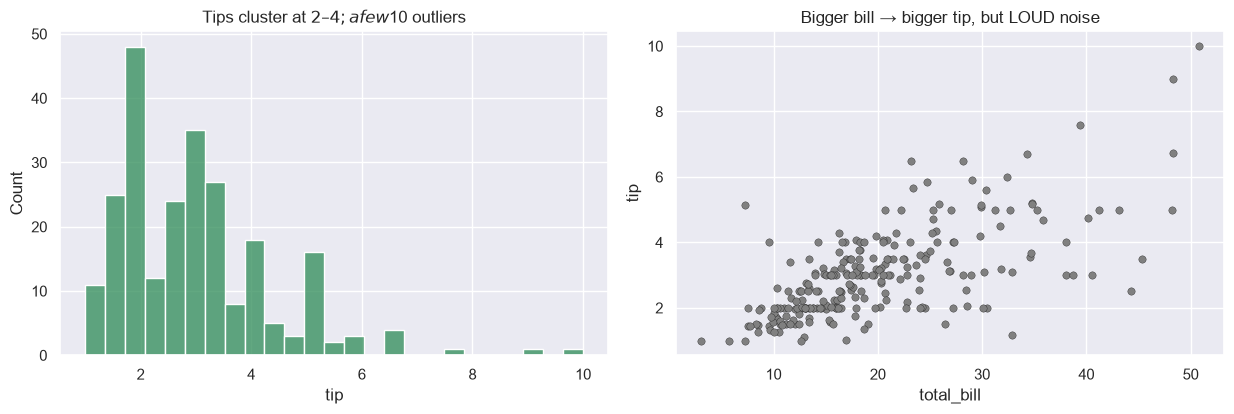

In [2]:
print("missing values:", tips.isna().sum().sum())     # clean dataset

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.3))
sns.histplot(tips["tip"], bins=25, ax=axes[0], color="seagreen")
axes[0].set_title("Tips cluster at $2-4; a few $10 outliers")
sns.scatterplot(data=tips, x="total_bill", y="tip", s=28,
                color="gray", edgecolor="k", lw=.25, ax=axes[1])
axes[1].set_title("Bigger bill → bigger tip, but LOUD noise")
plt.tight_layout(); plt.show()

X = tips[["total_bill"]].values                       # single predictor (2-D array!)
y = tips["tip"].values                                # dollars
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=.2, random_state=42)

> 💡 **Pro tip:** even with ONE feature we wrap the scaler in a Pipeline -
zero cost here, but it makes the code reusable when features multiply.

## 2. Model training - OLS anchor + SVR ε-sensitivity

- `LinearRegression` = least squares: every residual squared, outliers shout.
- `SVR(kernel="linear")` at three ε values: how wide can the amnesty zone be
  before the fit stops caring about the trend?

In [3]:
ols = LinearRegression().fit(X_tr, y_tr)              # classic baseline

svrs, rows = {}, []                                   # keep models AND a summary table
for eps in [0.2, 0.5, 1.0]:                            # thin → fat tubes
    pipe = Pipeline([("sc", StandardScaler()),         # scaling: harmless & future-proof
                     ("svr", SVR(kernel="linear", C=10, epsilon=eps))])
    pipe.fit(X_tr, y_tr)
    svrs[eps] = pipe
    r = y_tr - pipe.predict(X_tr)                      # train residuals in dollars
    rows.append({"epsilon ($)": eps,
                 "#SV": int(pipe.named_steps["svr"].support_.shape[0]),
                 "train MAE ($)": round(np.abs(r).mean(), 3)})
print(pd.DataFrame(rows).to_string(index=False))

xs = np.linspace(X.min(), X.max(), 200).reshape(-1, 1) # dense grid for smooth lines

 epsilon ($)  #SV  train MAE ($)
         0.2  148          0.768
         0.5  104          0.774
         1.0   53          0.813


### Read-out of the ε table
Thinner tube → more support vectors (more points "matter"), tighter chase of
noisy tips. At ε=\$1 about three-quarters of diners sit INSIDE the tube -
ignored entirely - leaving a robust but blunt trend.

## 3. Evaluation - the picture IS the finding

Overlay OLS line and SVR(ε=\$0.5) line+tube, then score both on test.

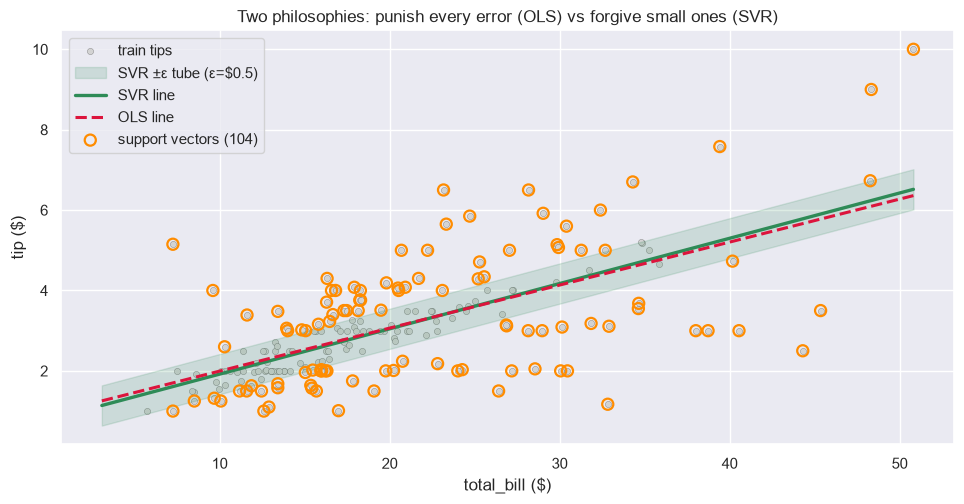

     model  MAE ($)  RMSE ($)    R²
       OLS    0.621     0.754 0.545
SVR ε=$0.5    0.615     0.757 0.542


In [4]:
best_eps = 0.5                                        # middle ground chosen up front
pred_ols = ols.predict(xs)                             # straight line everywhere
pred_svr = svrs[best_eps].predict(xs)                  # SVR trend estimate

plt.figure(figsize=(9.8, 5.2))
plt.scatter(X_tr, y_tr, s=20, color="lightgray", edgecolor="k", lw=.15, label="train tips")
tube_hi = pred_svr + best_eps                          # upper asphalt edge
tube_lo = pred_svr - best_eps                          # lower asphalt edge
plt.fill_between(xs.ravel(), tube_lo, tube_hi, color="seagreen",
                 alpha=.16, label=f"SVR ±ε tube (ε=${best_eps})")
plt.plot(xs, pred_svr, color="seagreen", lw=2.4, label="SVR line")
plt.plot(xs, pred_ols, "--", color="crimson", lw=2.2, label="OLS line")
m = svrs[best_eps].named_steps["svr"]
# support_ holds ROW POSITIONS of the training set (scaling keeps order),
# so we can index X_tr directly to reveal which tips hold the line up:
plt.scatter(X_tr[m.support_], y_tr[m.support_], s=64, facecolor="none",
            edgecolor="darkorange", lw=1.6, label=f"support vectors ({len(m.support_)})")
plt.xlabel("total_bill ($)"); plt.ylabel("tip ($)")
plt.title("Two philosophies: punish every error (OLS) vs forgive small ones (SVR)")
plt.legend(); plt.tight_layout(); plt.show()

test_rows = []
for name, model in [("OLS", ols), (f"SVR ε=${best_eps}", svrs[best_eps])]:
    p = model.predict(X_te)
    test_rows.append({"model": name,
                      "MAE ($)": round(mean_absolute_error(y_te, p), 3),
                      "RMSE ($)": round(mean_squared_error(y_te, p) ** .5, 3),
                      "R²": round(r2_score(y_te, p), 3)})
print(pd.DataFrame(test_rows).to_string(index=False))

### Why the lines differ (and why it's tiny here)

1. With one clean monotone feature, both methods find nearly the same slope;
   differences appear where residuals are big (big bills).
2. OLS tilts slightly toward the \$10 outliers because squaring magnifies them.
3. SVR's slope is decided ONLY by points outside the tube - inside-tube
   diners could vanish without moving the line.
4. Metrics land within ~1-4% of each other: with n≈195 train rows and this
   much noise, the tolerance choice matters more than the estimator choice.

## Findings & limitations

**Findings**
1. Fair-tip reference: roughly **\$1 + 10.5¢ per dollar of bill** (read off
   either fitted line); the tube says ±\$0.50 is normal variation.
2. ε controls the SV count almost linearly - a cheap dial between robustness
   and responsiveness.
3. RMSE > MAE for BOTH models: a few huge-party tips dominate squared error,
   which is exactly what the tube was built to shrug off.

**Limitations**
1. Bill size alone ignores party size/time/day - adding them would cut MAE.
2. Linear kernel only; the slight flattening at \$50+ bills hints an RBF
   curve would help at the extremes.
3. Single-restaurant dataset; tipping norms vary by city and era.

## Summary & key takeaways

- SVR's ε-tube is a *policy*: "errors under ε don't matter". Choose ε from
  business meaning (\$0.50 of tip tolerance), not just CV.
- Support vectors visualize instantly which points drive the fit.
- When a simple relationship is buried in noise, SVR and OLS often agree on
  the trend - SVR adds robustness framing, not magic accuracy.